## CS 5002 Project 1 Part 2
### Name: Wanjing Yang
### NU ID: 002442139

In [1]:
# ----- Import Packages -----
import numpy as np
import matplotlib.pyplot as plt

---
## Section 1. Cost Function to Evaluate the Performance of a Predictive Model

### 1.1 Read the data given on Canvas and split into two arrays x and y

In [2]:
def load_data(filename):
    """
    Load the data into two arrays

    Args:
        filename (str): The path to the text file containing the data (x, y)
    
    Return:
        array contraining the values of x
        array contraining the values of y
    """

    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

x, y = load_data('Source/data_chol_dias_pressure.txt')
print("x:", x)
print("y:", y)

x: [100.         110.52631579 121.05263158 131.57894737 142.10526316
 152.63157895 163.15789474 173.68421053 184.21052632 194.73684211
 205.26315789 215.78947368 226.31578947 236.84210526 247.36842105
 257.89473684 268.42105263 278.94736842 289.47368421 300.        ]
y: [58.94864536 61.42955826 65.66140653 68.15337824 67.46602089 69.37306594
 71.13458153 75.79139407 75.65104923 79.03581803 82.94976901 84.33271918
 86.13602117 87.3336793  90.14540532 89.99395303 94.16292736 97.16380543
 95.97742045 99.45334313]


### 1.2 Write a function which computes g(a, b) for any a and b

In [8]:
def cost_function_general (params, model_fn, x, y):
    """
    Compute the cost function for given parameters and a model function

    Args:
        params: A list or array containing the parameters such as (a, b)
        model_fn: The model function that takes parameters and x-values and returns predicted y-values
        x: The x-values of the data points
        y: The y-values of the data points

    Returns:
        The cost function value
    """
    cost = 0
    for i in range(len(x)):
        cost += (model_fn(params, x[i]) - y[i]) ** 2
    return cost

### 1.3 Gradient Descent Algorithm to find optimal a and b

The optimal a and optimal b calculated from the algorithem is -4336661677168.292, -16776077493.899841 respectively.

In [37]:
# First we can expand the previous approximate derivative functions to vectorized form:
def approx_df(params, f, h=0.00001):
    """
    A function that implements the approximate derivative
    
    Args:
        params: A list or array containing the parameters such as (a, b)
        f: The cost function to compute the cost for given parameters
        h: The step size for the finite difference approximation
    
    Returns:
        An array containing the approximate derivatives with respect to parmeters like (a, b)
    """
    params = np.array(params)
    n = len(params)
    df = np.zeros(n)

    for i in range(n):
        # Create a unit vector e_i with 1 at the i-th position and 0 elsewhere
        e_i = np.zeros(n)
        e_i[i] = 1
        # For the i-th parameter, compute the approximate derivative using finite difference
        df[i] = (f(params + h * e_i) - f(params)) / h

    return df

# As we learned matrix and the way to solve using np.linalg.norm, 
# we can implement the gradient descent algorithm with approximate derivatives as follows:
def GD_approx(f, approx_df, h, params0, alpha, epsilon, iter_max=1000):
    """
    A function that implements the gradient descent algorithm with approximate derivatives
    
    Args:
        f: The cost function to minimize
        approx_df: A function that computes the approximate derivative of f
        h: The step size for the finite difference approximation
        params0: Initial guess for the parameters, such as (a, b)
        alpha: Learning rate
        epsilon: Convergence threshold
        iter_max: Maximum number of iterations
    
    Returns:
        The optimal parameters such as (a, b) and the number of iterations taken to converge
    """
    iter = 0
    params_current = np.array(params0)

    while (iter < iter_max):
        params_next = params_current - alpha * approx_df(params_current, f, h)

        if np.linalg.norm(params_next - params_current) < epsilon:
            return params_next, iter
        else:
            params_current = params_next
            iter += 1

    return params_next, iter

In [47]:
linear_model = lambda params, x: params[0]*x + params[1]

fxy = lambda params: cost_function_general(params, linear_model, x, y)

params0 = [0.2, 40]  # Initial guess for (a, b)
param_opt, iter = GD_approx(fxy, approx_df, h=0.00001, params0=params0, alpha=0.01, epsilon=1e-6)
a_opt, b_opt = param_opt
print("Optimal parameters (a*, b*):", '{:.4f}, {:.4f}'.format(a_opt, b_opt))

Optimal parameters (a*, b*): -4336661677168.2920, -16776077493.8998


### 1.4 Plot the line along with the data points of original x and y

We can see from the first plot that the plotted line is not performing as expected. **Meaning the optimal value of a and b are not ideal.**

From a rough estimation, if we assume the data points follow a **linear relation**, we should be able to fit it as $y = 0.2x + 40$. As shown in the second plot.

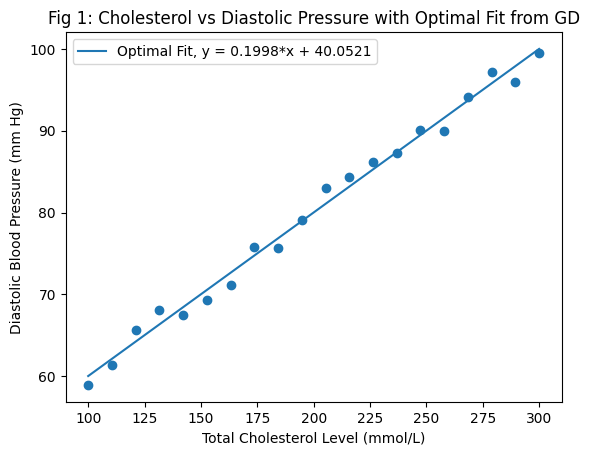

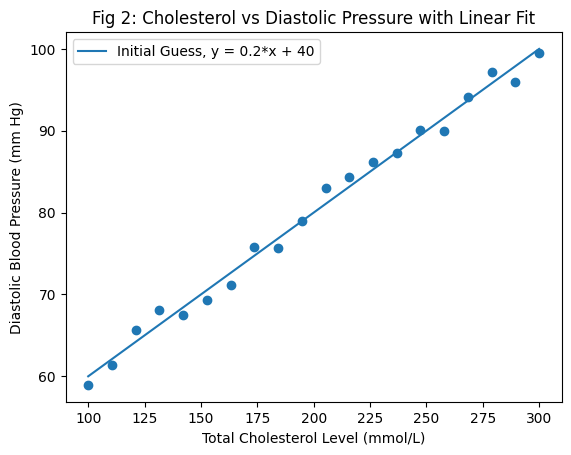

In [45]:
def plot_linear_fit(x, y, a, b, title, label=None, xlabel='Total Cholesterol Level (mmol/L)', ylabel='Diastolic Blood Pressure (mm Hg)'):
    plt.scatter(x, y)
    y_fit = a * x + b
    line_label = label if label else 'y = {:.4f}*x + {:.4f}'.format(a, b)
    plt.plot(x, y_fit, label=line_label)
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

plot_linear_fit(x, y, a_opt, b_opt,
                title='Fig 1: Cholesterol vs Diastolic Pressure with Optimal Fit from GD',
                label='Optimal Fit, y = {:.4f}*x + {:.4f}'.format(a_opt, b_opt))

plot_linear_fit(x, y, 0.2, 40,
                title='Fig 2: Cholesterol vs Diastolic Pressure with Linear Fit',
                label='Initial Guess, y = 0.2*x + 40')

### 1.5 Scaling Dataset to Find the Correct Value

It was not easy to find the correct value for the intitial parameers for gradient descent to converge.

It is because before scaling, the raw x values (~200) and y values (~60-100) create **a large scale difference between parameters a and b**, causing the cost function landscape to become an elongated ellipse rather than a symmetric bowl. This makes gradient descent unstable — any single learning rate α is either too large (overshooting in the steep direction) or too small (crawling in the flat direction). Standardizing the data brings all values to a similar scale (~0 to ±2), reshaping the landscape into a well-conditioned bowl that gradient descent can navigate efficiently regardless of the model used.

After scaling, we are able to find the correct optimal value for a and b as 

$$a^*=0.1998 \quad \text{and} \quad b^*=40.0521$$

And the fitting line looks good now with the updated values as in plot 3.


Optimal parameters (a*, b*) after transformation: 0.1998, 40.0521


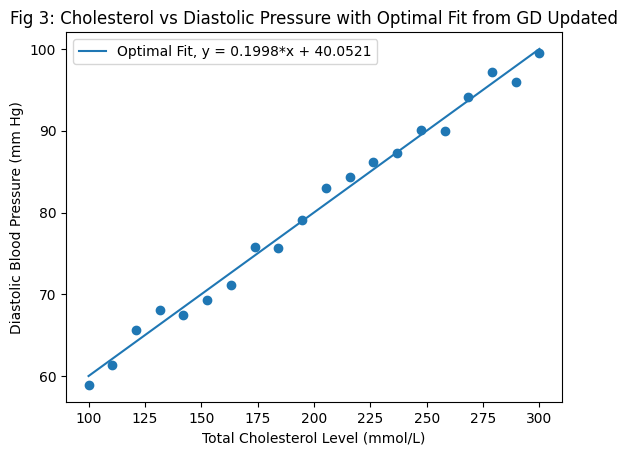

In [ ]:
# First we can scale the data to have zero mean and unit variance, which can help improve the convergence of gradient descent:
def scale_data(x, y):
    """
    Scale the data to have zero mean and unit variance

    Args:
        x: The x-values of the data points
        y: The y-values of the data points
    
    Returns:
        Scaled x and y values
    """

    x_scaled = (x - np.mean(x)) / np.std(x)
    y_scaled = (y - np.mean(y)) / np.std(y)
    return x_scaled, y_scaled

# After we get the optimal parameters in the scaled space, we can transform them back to the original space using the following function:
def transform_params(params, x, y):
    """
    Transform the parameters from the scaled space back to the original space

    Args:
        params: A list or array containing the parameters such as (a, b) in the scaled space
        x: The original x-values of the data points
        y: The original y-values of the data points

    Returns:
        Transformed parameters in the original space
    """
    a_scaled, b_scaled = params
    a_original = a_scaled * (np.std(y) / np.std(x))
    b_original = np.mean(y) - a_original * np.mean(x)
    return a_original, b_original


x_scaled, y_scaled = scale_data(x, y)
linear_model = lambda params, x: params[0]*x + params[1]
fxy = lambda params: cost_function_general(params, linear_model, x_scaled, y_scaled)

params0 = [0.2, 40]  # Initial guess for (a, b)
param_opt, iter = GD_approx(fxy, approx_df, h=0.00001, params0=params0, alpha=0.01, epsilon=1e-6)
a_opt, b_opt = transform_params(param_opt, x, y)
print("Optimal parameters (a*, b*) after transformation:", '{:.4f}, {:.4f}'.format(a_opt, b_opt))


plot_linear_fit(x, y, a_opt, b_opt,
                title='Fig 3: Cholesterol vs Diastolic Pressure with Optimal Fit from GD Updated',
                label='Optimal Fit, y = {:.4f}*x + {:.4f}'.format(a_opt, b_opt))


---
## Section 2. Non-linear Data

### 2.1 Read the data given on Canvas and split into two arrays x and y

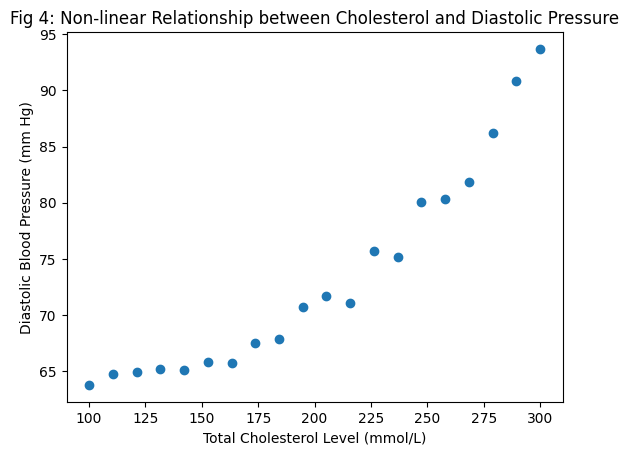

In [49]:
x_non_lin, y_non_lin = load_data('Source/data_chol_dias_pressure_non_lin.txt')
plt.scatter(x_non_lin, y_non_lin)
plt.xlabel('Total Cholesterol Level (mmol/L)')
plt.ylabel('Diastolic Blood Pressure (mm Hg)')
plt.title('Fig 4: Non-linear Relationship between Cholesterol and Diastolic Pressure')
plt.show()

In [ ]:
### 2.1 Read the data given on Canvas and split into two arrays x and y

### 2.2 Apply the Gradient Descent algorithm and get the optimal a and b

By applying the GD algorithm, we find the optimal value for a and b as 

$$a^*=0.1400 \quad \text{and} \quad b^*=45.3867$$

In [51]:
x_scaled, y_scaled = scale_data(x_non_lin, y_non_lin)
linear_model = lambda params, x: params[0]*x + params[1]
fxy = lambda params: cost_function_general(params, linear_model, x_scaled, y_scaled)

params0 = [0.2, 40]  # Initial guess for (a, b)
param_opt, iter = GD_approx(fxy, approx_df, h=0.00001, params0=params0, alpha=0.01, epsilon=1e-6)
a_opt, b_opt = transform_params(param_opt, x_non_lin, y_non_lin)
print("Optimal parameters (a*, b*) after transformation:", '{:.4f}, {:.4f}'.format(a_opt, b_opt))


Optimal parameters (a*, b*) after transformation: 0.1400, 45.3867


### 2.3 Plot the line and see how it perform

The plotted line perform not very well. This is because we can see from the chart that the data is not linear, so a linear line $y = a^{*} x + b^{*}$ will not show a good fitting.


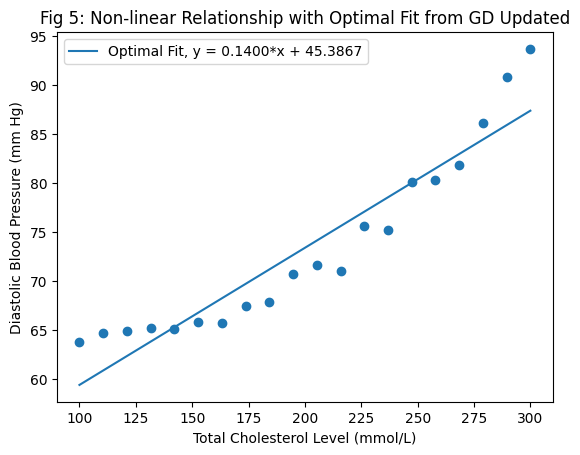

In [53]:
plot_linear_fit(x_non_lin, y_non_lin, a_opt, b_opt,
                title='Fig 5: Non-linear Relationship with Optimal Fit from GD Updated',
                label='Optimal Fit, y = {:.4f}*x + {:.4f}'.format(a_opt, b_opt))

### 2.4 Possible modifications to improve its performance - Consider non-linear model

By looking at the scatter plot of the non-linear data, we can see that the data points do not follow a linear pattern.

We can consider non-linear models. Since the scatter plot seems to follow a quadratic model, try:  $$f(x) = ax^2 + bx +c$$

As we can see from Fig 6, quadratic model fits well for the non-linear data set with a function as: $$ y = 0.0009 x^2 -0.2052x + 76.7295$$

In [ ]:
# Some helper functions for the non-linear model fitting:

# Transform the parameters back to the original space
def transform_quad_params(params, x, y):
    """
    Transform quadratic model parameters from scaled (x_s, y_s) space back to 
    original (x, y) space, where x_s = (x - μ_x)/σ_x and y_s = (y - μ_y)/σ_y.
    
    Scaled model:    y_s = a_s * x_s^2 + b_s * x_s + c_s
    Original model:  y   = A * x^2 + B * x + C
    """
    a_s, b_s, c_s = params
    mu_x, sigma_x = np.mean(x), np.std(x)
    mu_y, sigma_y = np.mean(y), np.std(y)

    A = a_s * sigma_y / (sigma_x ** 2)
    B = (b_s * sigma_y / sigma_x) - (2 * a_s * sigma_y * mu_x / (sigma_x ** 2))
    C = (a_s * sigma_y * (mu_x ** 2) / (sigma_x ** 2)
         - b_s * sigma_y * mu_x / sigma_x
         + c_s * sigma_y
         + mu_y)
    return A, B, C

# A function to plot the quadratic fit
def plot_quadratic_fit(x, y, a, b, c, title, label=None, xlabel='Total Cholesterol Level (mmol/L)', ylabel='Diastolic Blood Pressure (mm Hg)'):
    plt.scatter(x, y)
    y_fit = a * x**2 + b * x + c
    line_label = label if label else 'y = {:.4f}*x^2 + {:.4f}*x + {:.4f}'.format(a, b, c)
    plt.plot(x, y_fit, label=line_label)
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

Optimal parameters (a*, b*, c*) for quadratic model after transformation: 0.0009, -0.2052, 76.7295


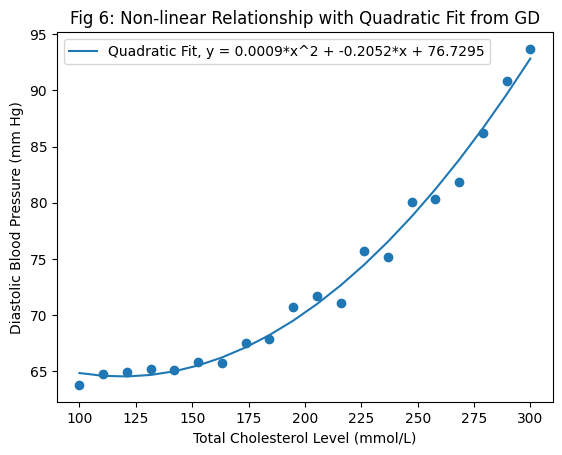

In [73]:
quadratic_model = lambda params, x: params[0]*x**2 + params[1]*x + params[2]
fxy_quad = lambda params: cost_function_general(params, quadratic_model, x_scaled, y_scaled)

params0_quad = [0.0, 0.0, 0.0]  # Initial guess for (a, b, c)

param_opt_quad, iter_quad = GD_approx(fxy_quad, approx_df, h=0.00001, params0=params0_quad, alpha=0.01, epsilon=1e-6, iter_max=1000)


a_opt_quad, b_opt_quad, c_opt_quad = transform_quad_params(param_opt_quad, x_non_lin, y_non_lin)
print("Optimal parameters (a*, b*, c*) for quadratic model after transformation:", '{:.4f}, {:.4f}, {:.4f}'.format(a_opt_quad, b_opt_quad, c_opt_quad))
plot_quadratic_fit(x_non_lin, y_non_lin, a_opt_quad, b_opt_quad, c_opt_quad,
                   title='Fig 6: Non-linear Relationship with Quadratic Fit from GD',
                   label='Quadratic Fit, y = {:.4f}*x^2 + {:.4f}*x + {:.4f}'.format(a_opt_quad, b_opt_quad, c_opt_quad))